<a href="https://colab.research.google.com/github/May-o-nnaise/CPSMA-4313-MS/blob/main/Data_Collecting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Create Data

By Mason Simpson

CPSMA-4313-01

Dr. Jacobs

In [24]:
!pip install google-colab-selenium

First and foremost, always gotta load this

##Website Used

In [25]:
import requests
from bs4 import BeautifulSoup
import pandas as pa

url = "https://www.basketball-reference.com/leagues/NBA_2026_games.html"

r = requests.get(url)
soup = BeautifulSoup(r.text)

soup.find_all('table')

[]

For the website, I used basketball-reference.com this is a basketball website that has a lot of raw data but it for whatever reason did not have the data i needed in its entirity. What I want to see is every buzzer beater and every shot that was attempted basketball reference only has every buzzer beater that was made and won a game. (https://www.basketball-reference.com/friv/buzzer-beaters.html). Since they dont have what I need. I plan on having selenium go through and go to each games play by play and check the last 3 seconds to see who attempted a shot and whether or not they missed it. To get to the page where all the games are I went to [all the games for the 2026 season](https://www.basketball-reference.com/leagues/NBA_2026_games.html).

In [26]:
from selenium.webdriver.chrome.options import Options
import google_colab_selenium as gs

custom_options = Options()
custom_options.add_argument("--headless")
# Add your custom options here

driver = gs.Chrome(options=custom_options)

<IPython.core.display.Javascript object>

You also have to import this too i forgot

##Getting Each Game

In [27]:
from io import StringIO

driver.get(url)
soup = BeautifulSoup(driver.page_source, 'html.parser')
tables = soup.find_all('table')

game_links = []
if tables:
    schedule_table = tables[0]  # Assuming the first table is the schedule table
    rows = schedule_table.find_all('tr')
    for row in rows:
        box_score_link_tag = row.find('a', string='Box Score')
        if box_score_link_tag and 'href' in box_score_link_tag.attrs:
            game_links.append('https://www.basketball-reference.com' + box_score_link_tag['href'])

print(f"Found {len(game_links)} game links.")
# For demonstration, print the first few links
if game_links:
     print("First 5 game links:")
     for link in game_links[:5]:
         print(link)

Found 80 game links.
First 5 game links:
https://www.basketball-reference.com/boxscores/202510210OKC.html
https://www.basketball-reference.com/boxscores/202510210LAL.html
https://www.basketball-reference.com/boxscores/202510220CHO.html
https://www.basketball-reference.com/boxscores/202510220NYK.html
https://www.basketball-reference.com/boxscores/202510220ORL.html


Okay, I pointed selenium to the website and I wanted it to copy the link for box score link the reason why is because this is the quickest way to get to the play by play for the games and it works for every game. If I tried to do it by date it, the website has this weird thing where it will arrange the games in a certain way that is not consistent for every day because some days have more games played than others. This did work and I had it print the first 5 games just to verify it was working correctly. I wanted to start with the first month being october where there were 80 games played.

##Getting That Play-by-Play Table

Navigating to the first game link: https://www.basketball-reference.com/boxscores/202510210OKC.html
Cookie consent window detected. Attempting to dismiss.
No cookie consent banner found or dismissed within the timeout.
Attempting to close any ad/pop-up with 'x' or close button.
No ad/pop-up close button found within the timeout.
Scrolling down the page...
Screenshot saved as 'selenium_screenshot_before_pbp.png' before clicking Play-By-Play link.


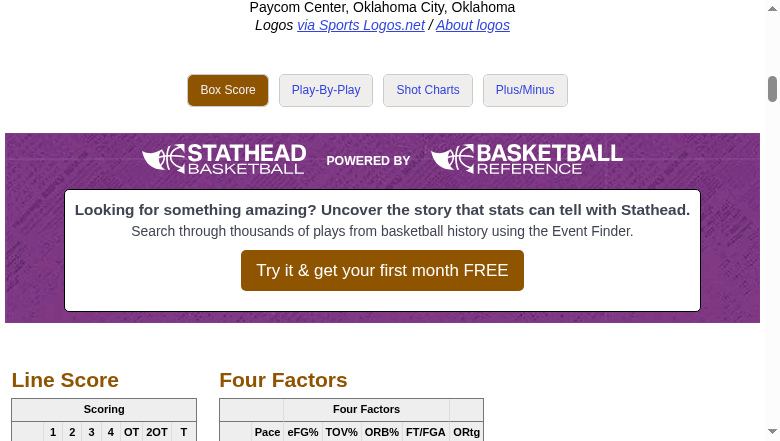

Successfully clicked on 'Play-By-Play'.
Current URL after clicking:  https://www.basketball-reference.com/boxscores/pbp/202510210OKC.html


In [28]:
import time
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from selenium.common.exceptions import TimeoutException, NoSuchElementException, WebDriverException
from IPython.display import Image, display

# Take the very first game link
if game_links:
    first_game_link = game_links[0]
    print(f"Navigating to the first game link: {first_game_link}")
    driver.get(first_game_link)
    time.sleep(5) # Give the page some time to load initially

    # Attempt to dismiss cookie consent banner if present
    try:
        # Wait for the cookie consent window to be present in the DOM (adjust class/id if needed)
        WebDriverWait(driver, 5).until(
            EC.presence_of_element_located((By.CLASS_NAME, 'osano-cm-window'))
        )
        print("Cookie consent window detected. Attempting to dismiss.")

        # Now find and click the accept button within the consent window
        # This XPath tries to find a button with 'accept' or 'agree' text, or a specific class
        accept_button = WebDriverWait(driver, 5).until(
            EC.element_to_be_clickable((
                By.XPATH, "//div[contains(@class, 'osano-cm-window')]//button[contains(@class, 'osano-cm-accept-all')] | "
                          "//div[contains(@class, 'osano-cm-window')]//button[contains(text(), 'Accept All')] | "
                          "//div[contains(@class, 'osano-cm-window')]//button[contains(text(), 'Agree')]"
            ))
        )
        accept_button.click()
        print("Cookie consent banner dismissed.")
        time.sleep(3) # Wait for the banner to disappear and page to adjust
    except TimeoutException:
        print("No cookie consent banner found or dismissed within the timeout.")
    except Exception as e:
        print(f"An error occurred while trying to dismiss cookie banner: {e}")

    # Attempt to close any general ad/pop-up with an 'x' or close button
    try:
        print("Attempting to close any ad/pop-up with 'x' or close button.")
        # Common XPaths for close buttons: by text, by class, by title
        close_button = WebDriverWait(driver, 5).until(
            EC.element_to_be_clickable((
                By.XPATH, "//button[contains(text(), 'x')] | "
                          "//button[contains(text(), 'X')] | "
                          "//div[contains(@class, 'close-button')] | "
                          "//a[contains(@class, 'close-button')] | "
                          "//button[@aria-label='Close'] | "
                          "//span[contains(text(), 'Close')]"
            ))
        )
        close_button.click()
        print("Ad/pop-up close button clicked.")
        time.sleep(2) # Give some time for the ad to disappear
    except TimeoutException:
        print("No ad/pop-up close button found within the timeout.")
    except Exception as e:
        print(f"An error occurred while trying to close ad/pop-up: {e}")

    # Scroll down the page to ensure the element is visible
    print("Scrolling down the page...")
    driver.execute_script("window.scrollBy(0, 1000);") # Scroll down by 1000 pixels
    time.sleep(2) # Give some time for the scroll to complete

    # Capture screenshot before attempting to click Play-By-Play link to diagnose interception
    screenshot_filename = 'selenium_screenshot_before_pbp.png'
    driver.save_screenshot(screenshot_filename)
    print(f"Screenshot saved as '{screenshot_filename}' before clicking Play-By-Play link.")
    display(Image(screenshot_filename))

    # Now, attempt to click the 'Play-By-Play' link
    try:
        # Use a more specific XPath to find the link by its text and partial href
        play_by_play_link_element = WebDriverWait(driver, 10).until(
            EC.element_to_be_clickable((
                By.XPATH, "//a[contains(@href, '/boxscores/pbp/') and text()='Play-By-Play']"
            ))
        )
        play_by_play_link_element.click()
        print("Successfully clicked on 'Play-By-Play'.")
        print("Current URL after clicking: ", driver.current_url)
    except Exception as e:
        print(f"An error occurred while trying to click the 'Play-By-Play' link: {e}")
else:
    print("No game links found to navigate to.")

There was far more troubleshooting than this but I removed some of the other mishaps that happened. I did not write this code I had gemeni do it because I am not very familiar with using selenium. This took quite a few tries for me to get it to produce what I was looking for so I started having it produce a screenshot of what it was looking at and for a while selenium kept getting stuck at the top of the page because there was an ad so there used to be a lot more screenshots of the top of the page. BUT eventually I got it to show me the "Play-by-Play" button on the screen by literally asking it to scroll down the page but it didnt think it was there for some reason so I had to manaully go through and gave gemeni the html element tied to the button and it seemed to work once I got the button on screen. The bright side to this is once I got it to do it once, I knew it was possible for the rest of them.

##Making That **NEW** Table

In [32]:
import time
import pandas as pd
from bs4 import BeautifulSoup
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from selenium.common.exceptions import TimeoutException, NoSuchElementException, WebDriverException
from IPython.display import Image, display
from io import StringIO
import re # Import regex module

# List to store results for all games
all_games_last_shot_data = []

# Helper function to parse shot descriptions
def parse_shot_description(description):
    if pd.isna(description):
        return None, None

    description = str(description)

    # Patterns for field goals (jump shot, dunk, layup, etc.)
    field_goal_pattern = re.compile(r"^([A-Za-z]\.\s[A-Za-z'-]+)\s(misses|makes)\s(\d-pt\s(?:jump shot|layup|dunk|floating jump shot|tip shot|hook shot|pullup jump shot|fadeaway jump shot|step back jump shot|driving layup|driving dunk|reverse layup|driving floating jump shot|driving hook shot|driving bank shot|running jump shot|running layup|running dunk|running floating jump shot|running hook shot|running bank shot))\s(?:from\s\d+\sft|)")

    # Patterns for free throws
    free_throw_pattern = re.compile(r"^([A-Za-z]\.\s[A-Za-z'-]+)\s(misses|makes)\sfree\sthrow(?:\s\d\sof\s\d)?")

    # Try matching field goal pattern first
    match = field_goal_pattern.match(description)
    if match:
        player = match.group(1)
        outcome = "made" if match.group(2) == "makes" else "missed"
        return player, outcome

    # If not a field goal, try matching free throw pattern
    match = free_throw_pattern.match(description)
    if match:
        player = match.group(1)
        outcome = "made" if match.group(2) == "makes" else "missed"
        return player, outcome

    return None, None # Not a recognized shot description

# Helper function to convert time string to seconds
def time_to_seconds(time_str):
    try:
        minutes, seconds_ms = time_str.split(':')
        seconds, milliseconds = seconds_ms.split('.')
        return int(minutes) * 60 + int(seconds) + int(milliseconds) / 10
    except ValueError:
        return pd.NA # Handle cases where time format is not as expected


if game_links:
    print(f"Processing {len(game_links)} games...")
    for idx, game_link in enumerate(game_links):
        print(f"\n--- Processing Game {idx + 1}/{len(game_links)}: {game_link} ---")
        try:
            driver.get(game_link)
            time.sleep(3) # Give the page some time to load initially

            # --- Cookie Consent Dismissal (Re-used from previous step) ---
            try:
                WebDriverWait(driver, 3).until(
                    EC.presence_of_element_located((By.CLASS_NAME, 'osano-cm-window'))
                )
                accept_button = WebDriverWait(driver, 3).until(
                    EC.element_to_be_clickable((
                        By.XPATH, "//div[contains(@class, 'osano-cm-window')]//button[contains(@class, 'osano-cm-accept-all')] | "
                                  "//div[contains(@class, 'osano-cm-window')]//button[contains(text(), 'Accept All')] | "
                                  "//div[contains(@class, 'osano-cm-window')]//button[contains(text(), 'Agree')]"
                    ))
                )
                accept_button.click()
                # print("Cookie consent banner dismissed.") # Commented out per user request
                time.sleep(2)
            except TimeoutException:
                pass # Continue if no banner
            except Exception as e:
                print(f"An error occurred while trying to dismiss cookie banner for {game_link}: {e}")

            # --- Ad/Pop-up Dismissal (Re-used from previous step) ---
            try:
                close_button = WebDriverWait(driver, 3).until(
                    EC.element_to_be_clickable((
                        By.XPATH, "//button[contains(text(), 'x')] | "
                                  "//button[contains(text(), 'X')] | "
                                  "//div[contains(@class, 'close-button')] | "
                                  "//a[contains(@class, 'close-button')] | "
                                  "//button[@aria-label='Close'] | "
                                  "//span[contains(text(), 'Close')]"
                    ))
                )
                close_button.click()
                # print("Ad/pop-up close button clicked.") # Commented out per user request
                time.sleep(2)
            except TimeoutException:
                pass # Continue if no ad
            except Exception as e:
                print(f"An error occurred while trying to close ad/pop-up for {game_link}: {e}")

            # Scroll down to ensure elements are visible before clicking Play-By-Play
            driver.execute_script("window.scrollBy(0, 500);")
            time.sleep(1)

            # --- Attempt to remove any persistent overlays or banners using JavaScript ---
            # print("Attempting to remove potential overlays with JavaScript.") # Commented out per user request
            try:
                script = """
                var elements_to_hide = [
                    '.consent-modal',
                    '.fc-dialog-container',
                    '.qc-cmp2-container',
                    '.fixed-banner',
                    '.sticky-footer',
                    '.popup-overlay',
                    '.overlay',
                    '[id*="ad_div"]',
                    '[id*="Interstitial"]',
                    '[class*="modal-backdrop"]',
                    '[class*="popup-content"]'
                ];
                elements_to_hide.forEach(function(selector) {
                    var els = document.querySelectorAll(selector);
                    els.forEach(function(el) {
                        el.style.display = 'none';
                        el.style.visibility = 'hidden';
                        if (el.parentNode) {
                            el.remove();
                        }
                    });
                });
                document.body.style.overflow = 'visible';
                """
                driver.execute_script(script)
                time.sleep(1)
                # print("JavaScript executed to hide potential overlays.") # Commented out per user request
            except Exception as e:
                print(f"Error executing JavaScript to hide overlays for {game_link}: {e}")

            # --- Click 'Play-By-Play' link ---
            try:
                play_by_play_link_element = WebDriverWait(driver, 10).until(
                    EC.element_to_be_clickable((
                        By.XPATH, "//a[contains(@href, '/boxscores/pbp/') and text()='Play-By-Play']"
                    ))
                )
                play_by_play_link_element.click()
                # print("Successfully clicked on 'Play-By-Play' using direct click.") # Commented out per user request
            except WebDriverException as e:
                # print(f"Direct click failed, attempting JavaScript click for 'Play-By-Play': {e}") # Commented out per user request
                # Try JavaScript click as a fallback
                try:
                    js_click_script = "arguments[0].click();"
                    play_by_play_link_element = driver.find_element(By.XPATH, "//a[contains(@href, '/boxscores/pbp/') and text()='Play-By-Play']")
                    driver.execute_script(js_click_script, play_by_play_link_element)
                    # print("Successfully clicked on 'Play-By-Play' using JavaScript click.") # Commented out per user request
                except Exception as js_e:
                    print(f"JavaScript click also failed for 'Play-By-Play' for {game_link}: {js_e}")
                    raise # Re-raise to be caught by outer game-level try-except
            time.sleep(3) # Wait for PBP page to load

            # Scroll to the bottom of the Play-By-Play page
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(3)

            # Get the page source and parse with BeautifulSoup
            soup = BeautifulSoup(driver.page_source, 'html.parser')
            pbp_table = soup.find('table', {'id': 'pbp'}) or soup.find('table', {'class': 'stats_table'}) # Adjust ID/class as needed

            if pbp_table:
                dfs = pd.read_html(StringIO(str(pbp_table)))
                if dfs:
                    df = dfs[0] # Assuming the first table is the one we want

                    # Clean up column headers
                    if isinstance(df.columns, pd.MultiIndex):
                        df.columns = ['_'.join(col).strip() for col in df.columns.values]
                        df.columns = df.columns.str.replace(r'Unnamed: \d+_', '', regex=True).str.strip('_')
                    else:
                        df.columns = df.columns.str.strip()

                    # Find and rename the 'Time' column
                    time_col_name = None
                    for col in df.columns:
                        # Fix: Removed newline from regex pattern
                        if df[col].astype(str).str.contains(r'^\d{1,2}:\d{2}\.\d$', na=False).any():
                            time_col_name = col
                            break

                    if time_col_name:
                        if time_col_name != 'Time':
                            df = df.rename(columns={time_col_name: 'Time'})

                        # Filter for rows where 'Time' column is not NaN and is in HH:MM.S format
                        # Fix: Removed newline from regex pattern
                        df_filtered = df[df['Time'].astype(str).str.contains(r'^\d{1,2}:\d{2}\.\d$', na=False)].copy()
                        df_filtered['Time_in_seconds'] = df_filtered['Time'].apply(time_to_seconds)

                        # Identify last period
                        quarter_start_indices = []
                        if not df_filtered.empty:
                            quarter_start_indices.append(df_filtered.index[0]) # The first entry is always a start
                            for i in range(1, len(df_filtered)):
                                current_time = df_filtered.iloc[i]['Time_in_seconds']
                                previous_time = df_filtered.iloc[i-1]['Time_in_seconds']

                                # If current time is greater than previous, it signifies a new period start
                                if pd.notna(current_time) and pd.notna(previous_time) and current_time > previous_time:
                                    quarter_start_indices.append(df_filtered.index[i])

                        df_last_period_plays = pd.DataFrame() # Initialize an empty DataFrame

                        if quarter_start_indices:
                            # The last element in quarter_start_indices is the start of the final period
                            start_of_last_period_idx = quarter_start_indices[-1]
                            df_last_period_plays = df_filtered.loc[start_of_last_period_idx:].copy()
                        else:
                            df_last_period_plays = df_filtered.copy()

                        # Filter for the last 3 seconds within this identified last period
                        shots_last_3_sec_game = df_last_period_plays[df_last_period_plays['Time_in_seconds'] <= 3.0].copy()

                        last_shooter = None
                        last_shot_outcome = None
                        last_shot_time = None
                        last_shot_description = None

                        if not shots_last_3_sec_game.empty:
                            shots_temp = shots_last_3_sec_game.reset_index(drop=False)
                            shots_sorted_for_last_play = shots_temp.sort_values(by=['Time_in_seconds', 'index'], ascending=[True, False])

                            for _, row in shots_sorted_for_last_play.iterrows():
                                # Dynamically get column names for descriptions (e.g., '1st Q.1', '1st Q.5')
                                # Assuming the two potential description columns are the second and second-to-last columns after 'Time' and 'Time_in_seconds' adjustment
                                description_col1_val = row.get(df.columns[1]) if len(df.columns) > 1 else None
                                description_col_far_right_val = row.get(df.columns[-2]) if len(df.columns) > 2 else None

                                player, outcome = parse_shot_description(description_col1_val)
                                if player is None: # If not found in primary description col, try secondary
                                    player, outcome = parse_shot_description(description_col_far_right_val)

                                if player and outcome:
                                    last_shooter = player
                                    last_shot_outcome = outcome.capitalize()
                                    last_shot_time = row['Time']
                                    last_shot_description = description_col1_val if pd.notna(description_col1_val) else description_col_far_right_val
                                    break # Found the last shot, exit loop

                        if last_shooter:
                            # print(f"Found last shot: {last_shooter} {last_shot_outcome} at {last_shot_time}") # Commented out per user request
                            all_games_last_shot_data.append({
                                'Game_Link': game_link,
                                'Last_Shooter': last_shooter,
                                'Shot_Outcome': last_shot_outcome,
                                'Time_of_Shot': last_shot_time,
                                'Description': last_shot_description
                            })
                        else:
                            # print("Could not find a shot attempt in the last 3 seconds of this game.") # Commented out per user request
                            all_games_last_shot_data.append({
                                'Game_Link': game_link,
                                'Last_Shooter': 'N/A',
                                'Shot_Outcome': 'N/A',
                                'Time_of_Shot': 'N/A',
                                'Description': 'No shot found in last 3 seconds'
                            })
                    else:
                        print(f"Could not find a 'Time' column for game: {game_link}")
                        all_games_last_shot_data.append({
                            'Game_Link': game_link,
                            'Last_Shooter': 'Error',
                            'Shot_Outcome': 'Error',
                            'Time_of_Shot': 'Error',
                            'Description': 'Time column not found'
                        })
                else:
                    print(f"No tables found by pandas.read_html for game: {game_link}")
                    all_games_last_shot_data.append({
                        'Game_Link': game_link,
                        'Last_Shooter': 'Error',
                        'Shot_Outcome': 'Error',
                        'Time_of_Shot': 'Error',
                        'Description': 'No tables found by pandas'
                    })
            else:
                print(f"Play-By-Play table not found on page for game: {game_link}")
                all_games_last_shot_data.append({
                    'Game_Link': game_link,
                    'Last_Shooter': 'Error',
                    'Shot_Outcome': 'Error',
                    'Time_of_Shot': 'Error',
                    'Description': 'Play-By-Play table not found'
                })

        except TimeoutException:
            print(f"Timeout occurred while processing {game_link}. Skipping this game.")
            screenshot_filename = f'error_screenshot_{idx}.png'
            driver.save_screenshot(screenshot_filename)
            print(f"Screenshot saved as '{screenshot_filename}' for game {idx + 1}.")
            display(Image(screenshot_filename))
            all_games_last_shot_data.append({
                'Game_Link': game_link,
                'Last_Shooter': 'Error',
                'Shot_Outcome': 'Error',
                'Time_of_Shot': 'Error',
                'Description': 'Timeout Exception - See screenshot for state at error'
            })
        except WebDriverException as e:
            print(f"WebDriver error while processing {game_link}: {e}. Skipping this game.")
            screenshot_filename = f'error_screenshot_{idx}.png'
            driver.save_screenshot(screenshot_filename)
            print(f"Screenshot saved as '{screenshot_filename}' for game {idx + 1}.")
            display(Image(screenshot_filename))
            all_games_last_shot_data.append({
                'Game_Link': game_link,
                'Last_Shooter': 'Error',
                'Shot_Outcome': 'Error',
                'Time_of_Shot': 'Error',
                'Description': f'WebDriver Error: {e} - See screenshot for state at error'
            })
        except Exception as e:
            print(f"An unexpected error occurred while processing {game_link}: {e}. Skipping this game.")
            screenshot_filename = f'error_screenshot_{idx}.png'
            driver.save_screenshot(screenshot_filename)
            print(f"Screenshot saved as '{screenshot_filename}' for game {idx + 1}.")
            display(Image(screenshot_filename))
            all_games_last_shot_data.append({
                'Game_Link': game_link,
                'Last_Shooter': 'Error',
                'Shot_Outcome': 'Error',
                'Time_of_Shot': 'Error',
                'Description': f'Unexpected Error: {e} - See screenshot for state at error'
            })

    # Convert results to DataFrame
    if all_games_last_shot_data:
        last_shots_summary_df = pd.DataFrame(all_games_last_shot_data)
        print("\n--- Summary of Last Shots for All Games ---")
        display(last_shots_summary_df)
    else:
        print("No game data processed.")
else:
    print("No game links were found to process.")

Processing 80 games...

--- Processing Game 1/80: https://www.basketball-reference.com/boxscores/202510210OKC.html ---

--- Processing Game 2/80: https://www.basketball-reference.com/boxscores/202510210LAL.html ---

--- Processing Game 3/80: https://www.basketball-reference.com/boxscores/202510220CHO.html ---

--- Processing Game 4/80: https://www.basketball-reference.com/boxscores/202510220NYK.html ---

--- Processing Game 5/80: https://www.basketball-reference.com/boxscores/202510220ORL.html ---

--- Processing Game 6/80: https://www.basketball-reference.com/boxscores/202510220BOS.html ---

--- Processing Game 7/80: https://www.basketball-reference.com/boxscores/202510220ATL.html ---

--- Processing Game 8/80: https://www.basketball-reference.com/boxscores/202510220CHI.html ---

--- Processing Game 9/80: https://www.basketball-reference.com/boxscores/202510220MEM.html ---

--- Processing Game 10/80: https://www.basketball-reference.com/boxscores/202510220MIL.html ---

--- Processing 

,Game_Link,Last_Shooter,Shot_Outcome,Time_of_Shot,Description
0,https://www.basketball-reference.com/boxscores...,J. Smith,Missed,0:00.0,J. Smith misses 2-pt jump shot from 20 ft
1,https://www.basketball-reference.com/boxscores...,N/A,N/A,N/A,No shot found in last 3 seconds
2,https://www.basketball-reference.com/boxscores...,N/A,N/A,N/A,No shot found in last 3 seconds
3,https://www.basketball-reference.com/boxscores...,D. Mitchell,Missed,0:03.0,D. Mitchell misses 3-pt jump shot from 25 ft
4,https://www.basketball-reference.com/boxscores...,B. Adebayo,Missed,0:03.0,B. Adebayo misses 3-pt jump shot from 28 ft
...,...,...,...,...,...
75,https://www.basketball-reference.com/boxscores...,O. Anunoby,Made,0:01.0,O. Anunoby makes 2-pt layup at rim
76,https://www.basketball-reference.com/boxscores...,N/A,N/A,N/A,No shot found in last 3 seconds
77,https://www.basketball-reference.com/boxscores...,N/A,N/A,N/A,No shot found in last 3 seconds
78,https://www.basketball-reference.com/boxscores...,A. Gordon,Missed,0:03.0,A. Gordon misses 2-pt jump shot from 16 ft (bl...


This took LEGITIMATELY ONE HOUR to finish. I in NO way think that this is going to work out since there are about 1000 games per season including every team and This was only for 80 games which would roughly take me about 12.5 hours and I would still have to get it to go through and make sure to go through every month played in the 2025-2026 season since this 80 games is just from october. The way I got this one to work was again by using gemeni I asked it to get the table on the very first [game](https://www.basketball-reference.com/boxscores/pbp/202510210OKC.html). I immediately ran into problems. I asked it to get the times at the very end of the table where there were 3 seconds, I didnt really think about it so It tried getting them all from the 1st-4th quarters but I was only really interested in the 4th quarter, then I realized that doesnt account for the games where it has to go into overtime (OT) and then I also forgot that the first game, OKC went into double OT so I had to have it fix that too. BUT after a lot of troubleshooting I was able to get it to print a table that was slightly incorrect, for some reason it only grabbed the two free throws that SGA made at 0:02 but that was not what I was looking for, I wanted to see who shot last in the last 3 seconds. However, I was able to correct this and I finally had my table with J. Smith who missed his buzzer beater, how sad sucks to lose to OKC am I right? Anyways then there were only 79 more games to go. I used the "tranform code" button and simply asked gemeni to repeat this process for each game from the table created in the previous cell and after a little bit it did this perfectly HOWEVER as mentioned it TOOK AN HOUR for it to get all the games. For that reason I am throwing in the towel and you only get 80 games. I also now understand why you wanted me to limit how many games I was going to scrape data from. I was really ready to shoot for the moon though.

##Results

/tmp/ipykernel_2771/2096782428.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')


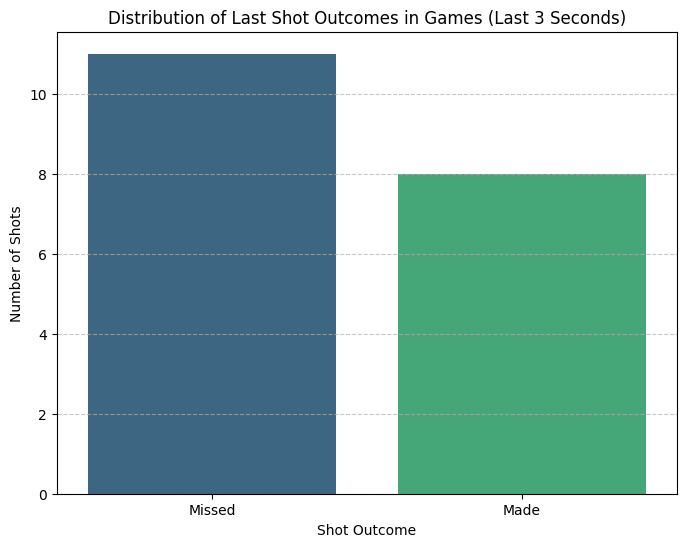

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 'N/A' and 'Error' entries for shots to only count actual shot outcomes
shot_outcomes = last_shots_summary_df[last_shots_summary_df['Shot_Outcome'].isin(['Made', 'Missed'])]

# Count the occurrences of each shot outcome
outcome_counts = shot_outcomes['Shot_Outcome'].value_counts()

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')
plt.title('Distribution of Last Shot Outcomes in Games (Last 3 Seconds)')
plt.xlabel('Shot Outcome')
plt.ylabel('Number of Shots')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Here is a bar chart of the missed versus the made shot attempts and you can see out of 80 games, only 21 buzzer beaters were attempted and over half of them ended up being missed. It just so happens that buzzer beaters would be the most contested shot in basketball so it makes sense as to why.

In [36]:
player_shot_summary = shot_outcomes.groupby('Last_Shooter')['Shot_Outcome'].value_counts().unstack(fill_value=0)
player_shot_summary['Total_Shots'] = player_shot_summary['Made'] + player_shot_summary['Missed']
player_shot_summary['Accuracy_Percentage'] = (player_shot_summary['Made'] / player_shot_summary['Total_Shots']) * 100

# Sort by Accuracy_Percentage and display
player_shot_summary = player_shot_summary.sort_values(by='Accuracy_Percentage', ascending=False)

print("\n--- Player-wise Shot Accuracy (Last Shot Attempt Within Last 3 Seconds) ---")
display(player_shot_summary)


--- Player-wise Shot Accuracy (Last Shot Attempt Within Last 3 Seconds) ---


Shot_Outcome,Made,Missed,Total_Shots,Accuracy_Percentage
Last_Shooter,,,,
C. Holmgren,1,0,1,100.0
A. Reaves,1,0,1,100.0
O. Anunoby,1,0,1,100.0
R. Kalkbrenner,1,0,1,100.0
H. Barnes,1,0,1,100.0
D. Cardwell,1,0,1,100.0
J. Walker,1,0,1,100.0
T. Young,1,1,2,50.0
A. Nesmith,0,1,1,0.0


Here is a table that breaks down the 21 shots and who shot them and what their percentage is apparently the only person with 2 buzzer beaters is Trae Young. I think this data would be a lot more interesting but Im not certain it is very feasible given the time contstraints of this assignment.

In [30]:
#driver.quit()